In [284]:
import polars as pl

import matplotlib.pyplot as plt

In [285]:
FILTER = "ASH_COATED_OSMIUM"
# FILTER = "INTARIAN_PEPPER_ROOT"

DAY = 0

In [286]:

# Quotes (order book snapshots)
quotes = pl.read_csv(
    f"data/orders_day{DAY}.csv",
    separator=";",
    null_values=[""]
)


# Trades
trades = pl.read_csv(
    f"data/trades_day{DAY}.csv",
    separator=";",
    null_values=[""]
)



quotes = quotes.filter(pl.col("product")==FILTER)
trades = trades.filter(pl.col("symbol")==FILTER)

print(quotes.head())
print(trades.head())

shape: (5, 17)
┌─────┬───────────┬────────────┬────────────┬───┬────────────┬────────────┬───────────┬────────────┐
│ day ┆ timestamp ┆ product    ┆ bid_price_ ┆ … ┆ ask_price_ ┆ ask_volume ┆ mid_price ┆ profit_and │
│ --- ┆ ---       ┆ ---        ┆ 1          ┆   ┆ 3          ┆ _3         ┆ ---       ┆ _loss      │
│ i64 ┆ i64       ┆ str        ┆ ---        ┆   ┆ ---        ┆ ---        ┆ f64       ┆ ---        │
│     ┆           ┆            ┆ i64        ┆   ┆ str        ┆ str        ┆           ┆ f64        │
╞═════╪═══════════╪════════════╪════════════╪═══╪════════════╪════════════╪═══════════╪════════════╡
│ 0   ┆ 0         ┆ ASH_COATED ┆ null       ┆ … ┆ null       ┆ null       ┆ 10013.0   ┆ 0.0        │
│     ┆           ┆ _OSMIUM    ┆            ┆   ┆            ┆            ┆           ┆            │
│ 0   ┆ 100       ┆ ASH_COATED ┆ 9995       ┆ … ┆ null       ┆ null       ┆ 10003.0   ┆ 0.0        │
│     ┆           ┆ _OSMIUM    ┆            ┆   ┆            ┆            ┆ 

In [287]:
quotes2 = pl.read_csv(
    f"data/orders_day2.csv",
    separator=";",
    null_values=[""]
).with_columns([
    pl.col("ask_price_3").cast(pl.Int64),
    pl.col("bid_price_3").cast(pl.Int64),
    pl.col("ask_volume_3").cast(pl.Int64),
    pl.col("bid_volume_3").cast(pl.Int64),
])

quotes1 = pl.read_csv(
    f"data/orders_day1.csv",
    separator=";",
    null_values=[""]
).with_columns([
    pl.col("ask_price_3").cast(pl.Int64),
    pl.col("bid_price_3").cast(pl.Int64),
    pl.col("ask_volume_3").cast(pl.Int64),
    pl.col("bid_volume_3").cast(pl.Int64),
])

quotes0 = pl.read_csv(
    f"data/orders_day0.csv",
    separator=";",
    null_values=[""]
).with_columns([
    pl.col("ask_price_3").cast(pl.Int64),
    pl.col("bid_price_3").cast(pl.Int64),
    pl.col("ask_volume_3").cast(pl.Int64),
    pl.col("bid_volume_3").cast(pl.Int64),
])

df = pl.concat([quotes0, quotes1, quotes2])

df

day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
i64,i64,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64
0,0,"""ASH_COATED_OSMIUM""",null,null,null,null,null,null,10013,30,null,null,null,null,10013.0,0.0
0,0,"""INTARIAN_PEPPER_ROOT""",11991,19,null,null,null,null,12006,10,12009,19,null,null,11998.5,0.0
0,100,"""INTARIAN_PEPPER_ROOT""",11994,9,11991,23,null,null,12007,9,12010,23,null,null,12000.5,0.0
0,100,"""ASH_COATED_OSMIUM""",9995,13,null,null,null,null,10011,13,10013,30,null,null,10003.0,0.0
0,200,"""INTARIAN_PEPPER_ROOT""",11991,20,null,null,null,null,12007,11,12010,20,null,null,11999.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
-2,999700,"""ASH_COATED_OSMIUM""",9984,10,9982,22,null,null,10000,10,10003,22,null,null,9992.0,0.0
-2,999800,"""INTARIAN_PEPPER_ROOT""",10994,11,10991,24,null,null,null,null,null,null,null,null,10994.0,0.0
-2,999800,"""ASH_COATED_OSMIUM""",9984,14,9982,25,null,null,null,null,null,null,null,null,9984.0,0.0


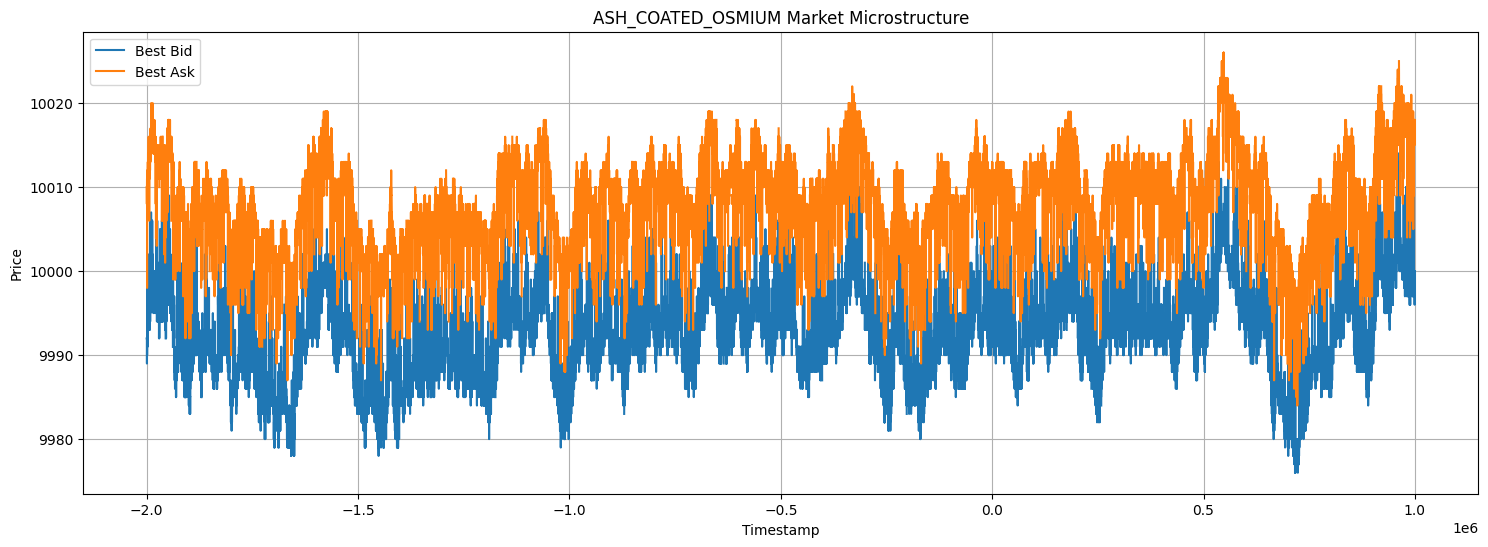

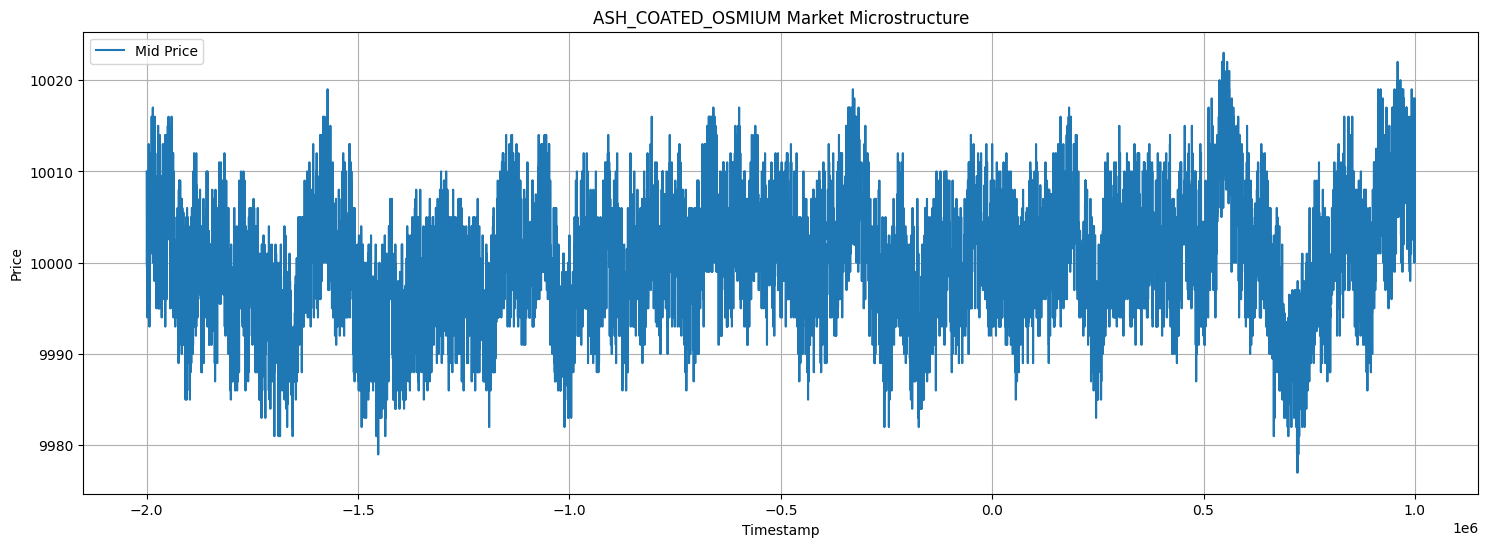

In [288]:

df = df.filter(pl.col("product") == FILTER)

df = df.with_columns(
    (pl.col("timestamp") + 1_000_000 * pl.col("day")).alias("timestamp")
).sort("timestamp").filter(pl.col("mid_price")!=0)

plt.figure(figsize=(18, 6))

# # # Order book lines
plt.plot(df["timestamp"], df["bid_price_1"], label="Best Bid")
plt.plot(df["timestamp"], df["ask_price_1"], label="Best Ask")
# plt.plot(df["timestamp"], df["mid_price"], label="Mid Price")

plt.title(f"{FILTER} Market Microstructure")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid()

plt.show()



plt.figure(figsize=(18, 6))

plt.plot(df["timestamp"], df["mid_price"], label="Mid Price")

plt.title(f"{FILTER} Market Microstructure")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid()

plt.show()


## Uhlenbeck Mean Reversion

In [289]:
import polars as pl
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import scipy.stats as stats

# =========================
# 1. LOAD & PREPARE DATA
# =========================


df_filtered = (
    quotes.filter(pl.col("product") == FILTER)
      .sort("timestamp")
      .select(["timestamp", "mid_price"])
      .drop_nulls()
)

# Convert to pandas Series
ts = df_filtered["mid_price"].to_pandas()

print("Number of observations:", len(ts))


# =========================
# 2. BASIC MEAN CHECK
# =========================
mean_price = ts.mean()
print("\n=== MEAN CHECK ===")
print("Sample mean:", mean_price)
print("Distance from 10,000:", abs(mean_price - 10000))


# =========================
# 3. ADF TEST AROUND 10,000
# =========================
y = ts - 10000

adf_result = adfuller(y)

print("\n=== ADF TEST (X - 10000) ===")
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("✅ Stationary around 10,000 → mean-reverting to 10k")
else:
    print("❌ Not stationary around 10,000")


# =========================
# 4. OU PARAMETER ESTIMATION
# =========================
ts_lag = ts.shift(1).dropna()
ts_now = ts.iloc[1:]

delta = ts_now.values - ts_lag.values

X = ts_lag.values.reshape(-1, 1)
X = np.hstack([np.ones_like(X), X])  # add intercept

beta = np.linalg.lstsq(X, delta, rcond=None)[0]

theta = -beta[1]
mu = beta[0] / theta if theta != 0 else np.nan

print("\n=== OU ESTIMATION ===")
print("Theta (mean reversion speed):", theta)
print("Estimated long-term mean (mu):", mu)
print("Distance mu from 10,000:", abs(mu - 10000))


# =========================
# 5. HALF-LIFE
# =========================
half_life = np.log(2) / theta if theta > 0 else np.inf

print("\n=== HALF-LIFE ===")
print("Half-life:", half_life)


# =========================
# 6. STATISTICAL TEST: MEAN == 10000
# =========================
std = ts.std()
n = len(ts)

t_stat = (mean_price - 10000) / (std / np.sqrt(n))
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n - 1))

print("\n=== T-TEST: mean == 10000 ===")
print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("❌ Reject: mean is NOT 10,000")
else:
    print("✅ Cannot reject: mean could be 10,000")


# =========================
# 7. FINAL INTERPRETATION
# =========================
print("\n=== FINAL SUMMARY ===")

if abs(mu - 10000) < 1:
    print("🔥 Strong evidence: price reverts to ~10,000")
elif abs(mu - 10000) < 5:
    print("⚠️ Weak evidence: near 10,000 but not exact")
else:
    print("❌ No evidence: reverts to a different level")

if adf_result[1] < 0.05:
    print("✔ Series is stationary (mean-reverting)")
else:
    print("✖ Series is not stationary")

Number of observations: 10000

=== MEAN CHECK ===
Sample mean: 9987.60595
Distance from 10,000: 12.394050000000789

=== ADF TEST (X - 10000) ===
ADF Statistic: -100.0952625296222
p-value: 0.0
✅ Stationary around 10,000 → mean-reverting to 10k

=== OU ESTIMATION ===
Theta (mean reversion speed): 1.0011020978292466
Estimated long-term mean (mu): 9987.60341100169
Distance mu from 10,000: 12.396588998310108

=== HALF-LIFE ===
Half-life: 0.6923841055402246

=== T-TEST: mean == 10000 ===
t-statistic: -3.3136895038941514
p-value: 0.0009240086652619883
❌ Reject: mean is NOT 10,000

=== FINAL SUMMARY ===
❌ No evidence: reverts to a different level
✔ Series is stationary (mean-reverting)


In [290]:
quotes = quotes.with_columns([
    pl.col("timestamp").cast(pl.Int64),
    pl.col("mid_price").cast(pl.Float64)
])

quotes = quotes.with_columns([
    pl.col("bid_price_1").alias("best_bid"),
    pl.col("ask_price_1").alias("best_ask"),
    (pl.col("ask_price_1") - pl.col("bid_price_1")).alias("spread")
])

trades = trades.with_columns([
    pl.col("timestamp").cast(pl.Int64),
    pl.col("price").cast(pl.Float64),
    pl.col("quantity").cast(pl.Int64)
])

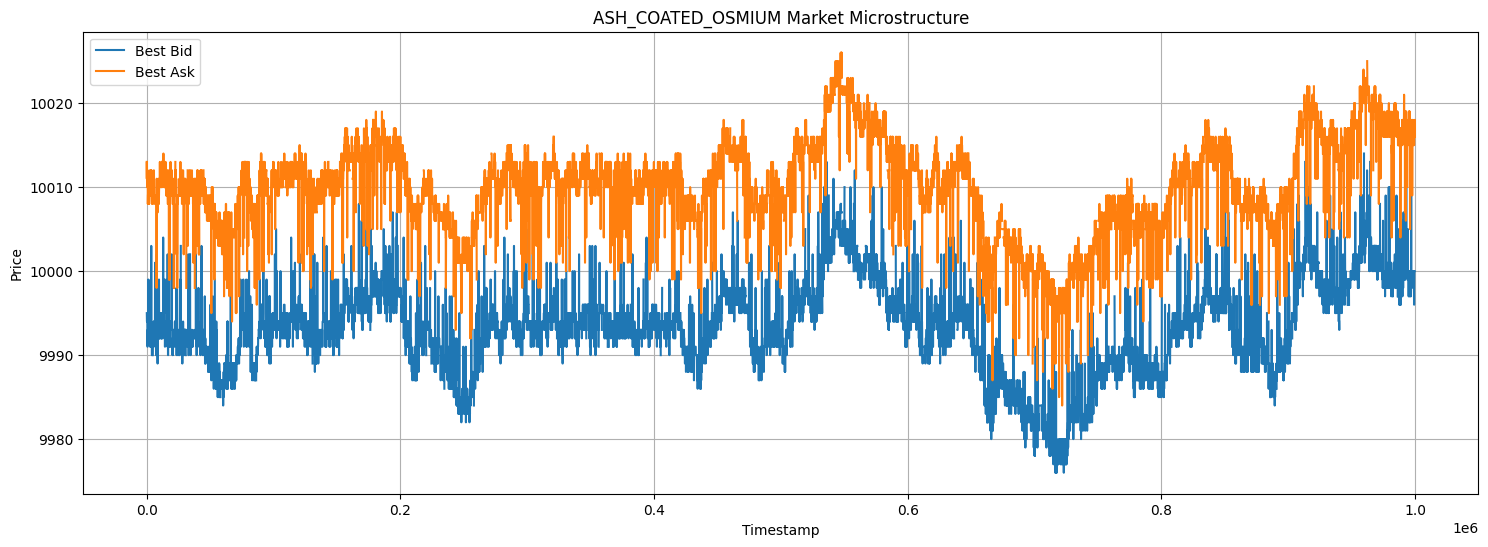

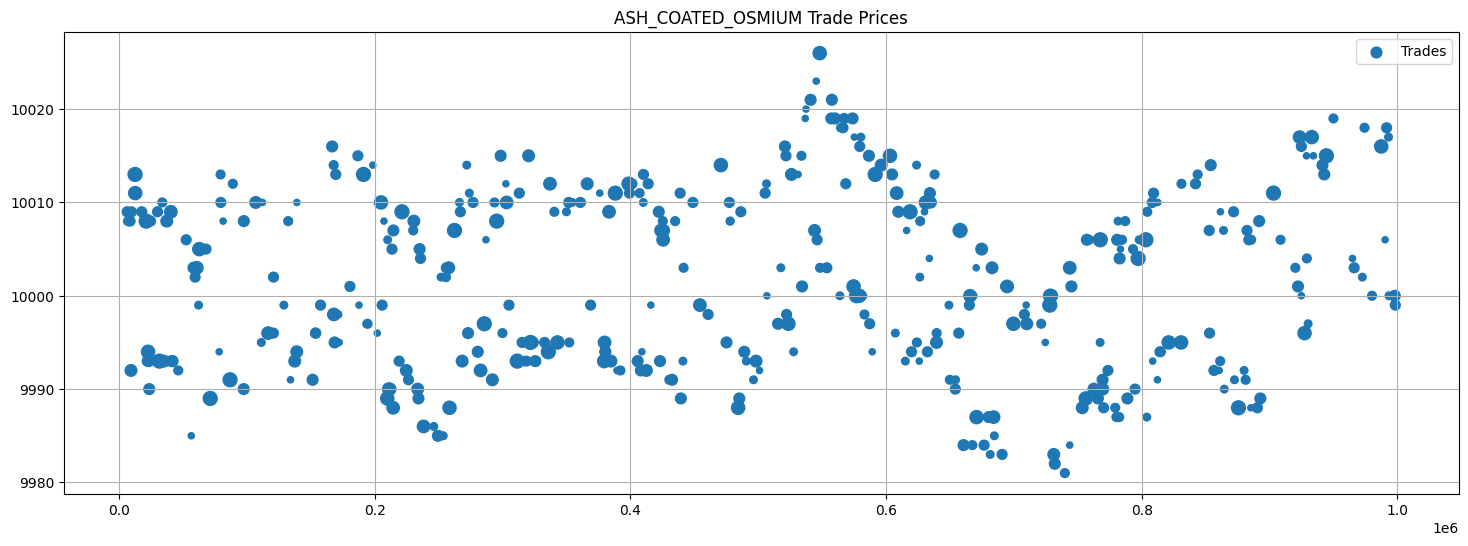

In [291]:

plt.figure(figsize=(18, 6))

# # Order book lines
plt.plot(quotes["timestamp"], quotes["best_bid"], label="Best Bid")
plt.plot(quotes["timestamp"], quotes["best_ask"], label="Best Ask")
# plt.plot(quotes["timestamp"], quotes["mid_price"], label="Mid Price")

plt.title(f"{FILTER} Market Microstructure")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid()

plt.show()


plt.figure(figsize=(18, 6))
plt.scatter(
    trades["timestamp"],
    trades["price"],
    s=trades["quantity"] * 10,
    marker="o",
    label="Trades"
)
plt.title(f"{FILTER} Trade Prices")
plt.legend()
plt.grid()

plt.show()


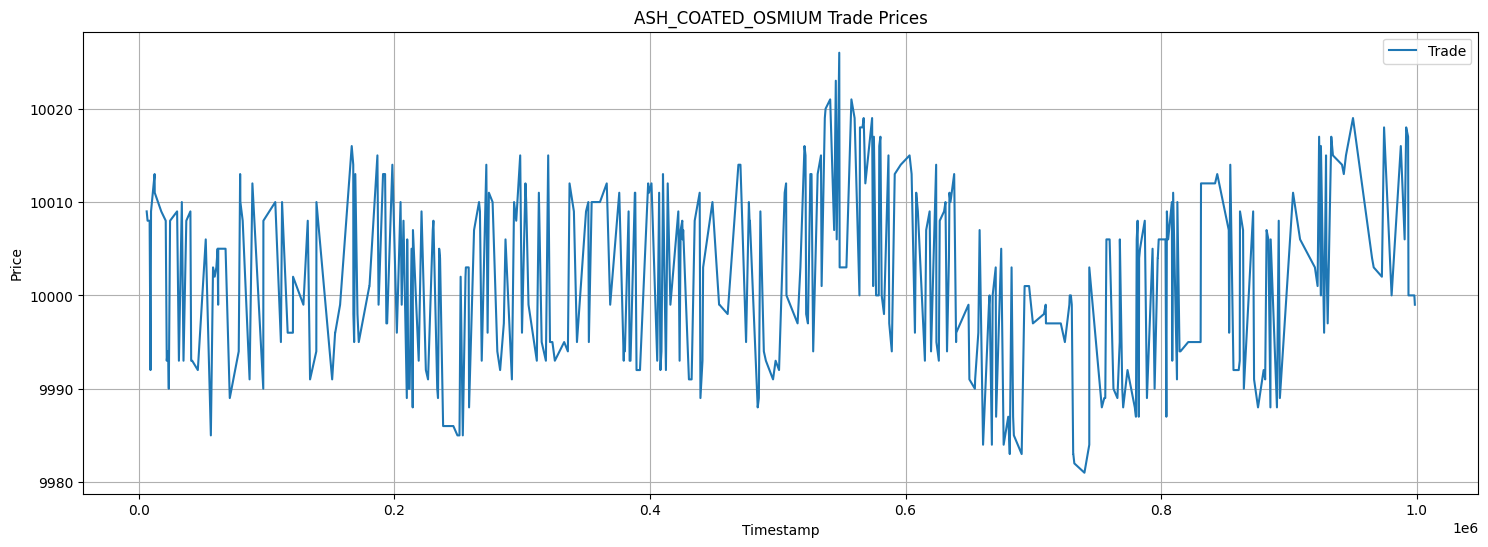

In [292]:
plt.figure(figsize=(18, 6))

# # Trade Prices
plt.plot(trades["timestamp"], trades["price"], label="Trade")

plt.title(f"{FILTER} Trade Prices")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid()

plt.show()


In [293]:

result = quotes.select([
    (pl.col("best_bid").diff().abs() > 3).sum().alias("bid_jumps"),
    (pl.col("best_ask").diff().abs() > 3).sum().alias("ask_jumps"),
])

print(result)

shape: (1, 2)
┌───────────┬───────────┐
│ bid_jumps ┆ ask_jumps │
│ ---       ┆ ---       │
│ u32       ┆ u32       │
╞═══════════╪═══════════╡
│ 790       ┆ 761       │
└───────────┴───────────┘


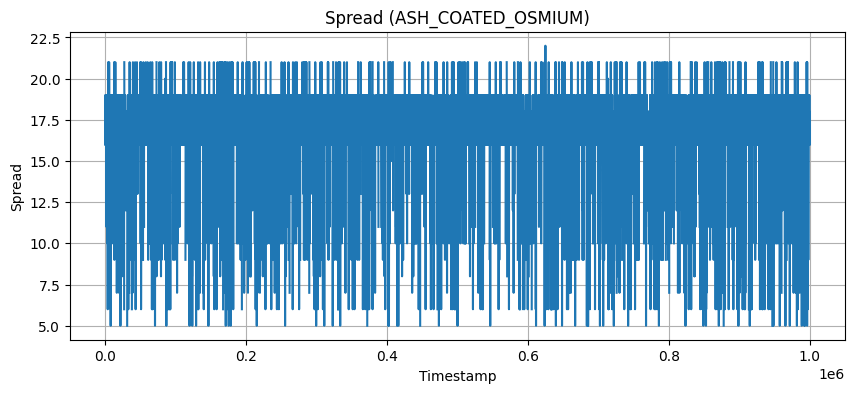

In [294]:
plt.figure(figsize=(10, 4))

plt.plot(quotes["timestamp"], quotes["spread"])

plt.title(f"Spread ({FILTER})")
plt.xlabel("Timestamp")
plt.ylabel("Spread")

plt.grid()
plt.show()

In [295]:
quotes

day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,best_bid,best_ask,spread
i64,i64,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,str,f64,f64,i64,i64,i64
0,0,"""ASH_COATED_OSMIUM""",null,null,null,null,null,null,10013,30,null,null,null,null,10013.0,0.0,null,10013,null
0,100,"""ASH_COATED_OSMIUM""",9995,13,null,null,null,null,10011,13,10013,30,null,null,10003.0,0.0,9995,10011,16
0,200,"""ASH_COATED_OSMIUM""",9994,13,9992,21,null,null,10013,21,null,null,null,null,10003.5,0.0,9994,10013,19
0,300,"""ASH_COATED_OSMIUM""",9994,11,9992,23,null,null,10010,11,10013,23,null,null,10002.0,0.0,9994,10010,16
0,400,"""ASH_COATED_OSMIUM""",9994,13,9991,23,null,null,10010,13,10012,23,null,null,10002.0,0.0,9994,10010,16
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,999500,"""ASH_COATED_OSMIUM""",10000,13,9997,28,null,null,10018,28,null,null,null,null,10009.0,0.0,10000,10018,18
0,999600,"""ASH_COATED_OSMIUM""",10000,14,9997,27,null,null,10016,14,10018,27,null,null,10008.0,0.0,10000,10016,16
0,999700,"""ASH_COATED_OSMIUM""",10000,11,9997,24,null,null,10016,11,10018,24,null,null,10008.0,0.0,10000,10016,16


Readable log written to: ../156488/156488_readable.log
TRADING LOG ANALYSIS

Total rows loaded : 1820
Products          : ['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']
Timestamp range   : 0 – 99900
Days in log       : [0]

--- Per-product summary ---
shape: (2, 12)
┌─────────────┬───────┬───────────┬─────────┬───┬────────────┬───────────┬────────────┬────────────┐
│ product     ┆ ticks ┆ final_pnl ┆ min_pnl ┆ … ┆ avg_mid    ┆ std_mid   ┆ avg_bid_vo ┆ avg_ask_vo │
│ ---         ┆ ---   ┆ ---       ┆ ---     ┆   ┆ ---        ┆ ---       ┆ l          ┆ l          │
│ str         ┆ u32   ┆ f64       ┆ f64     ┆   ┆ f64        ┆ f64       ┆ ---        ┆ ---        │
│             ┆       ┆           ┆         ┆   ┆            ┆           ┆ f64        ┆ f64        │
╞═════════════╪═══════╪═══════════╪═════════╪═══╪════════════╪═══════════╪════════════╪════════════╡
│ ASH_COATED_ ┆ 910   ┆ 3937.3125 ┆ 0.0     ┆ … ┆ 9999.99340 ┆ 3.42746   ┆ 14.880046  ┆ 14.578231  │
│ OSMIUM      ┆       ┆    

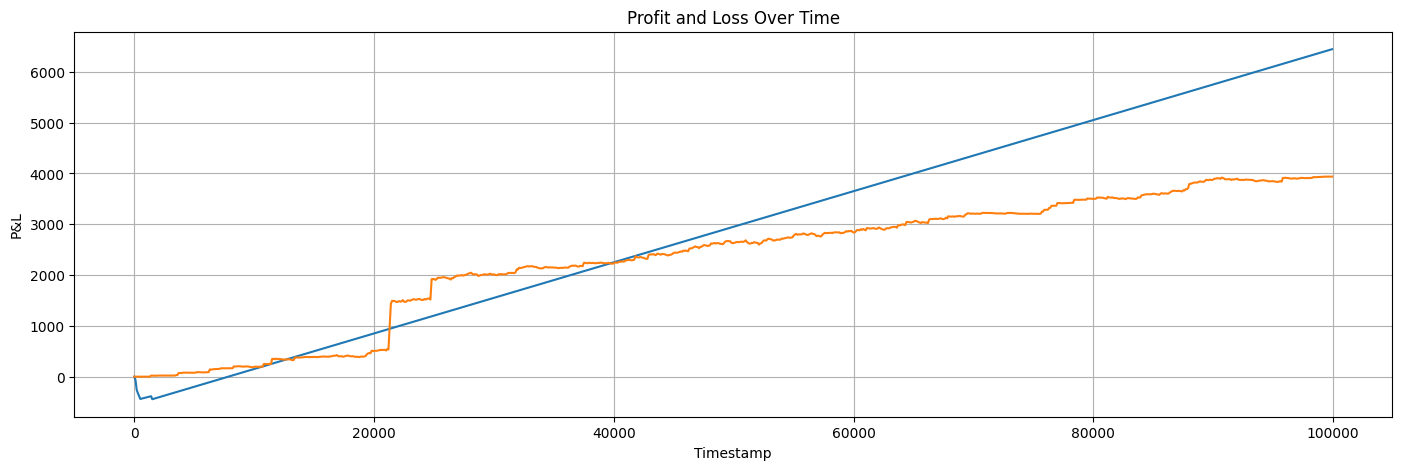

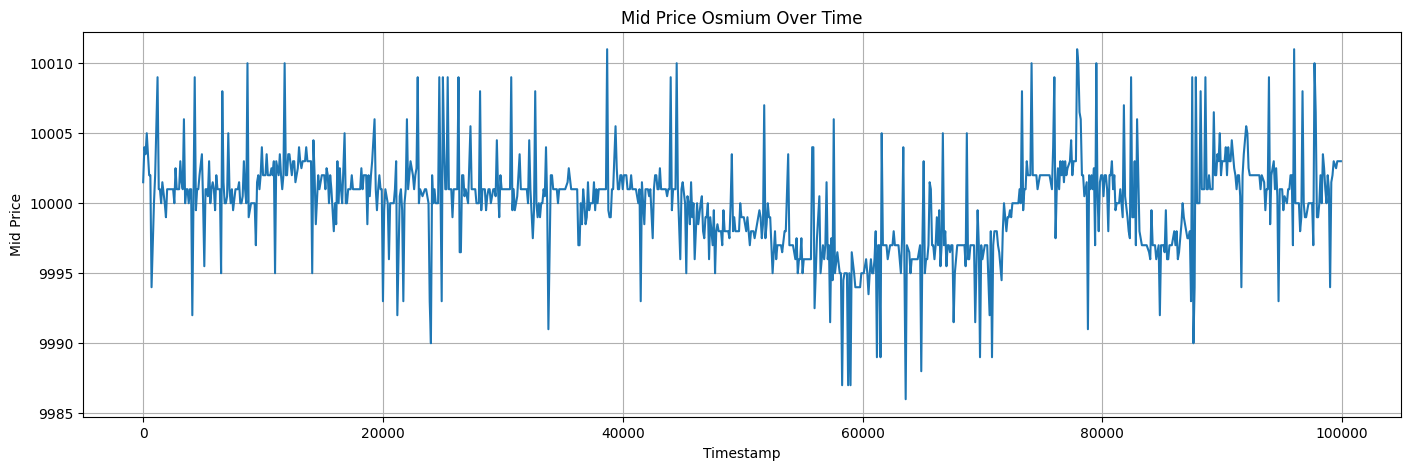

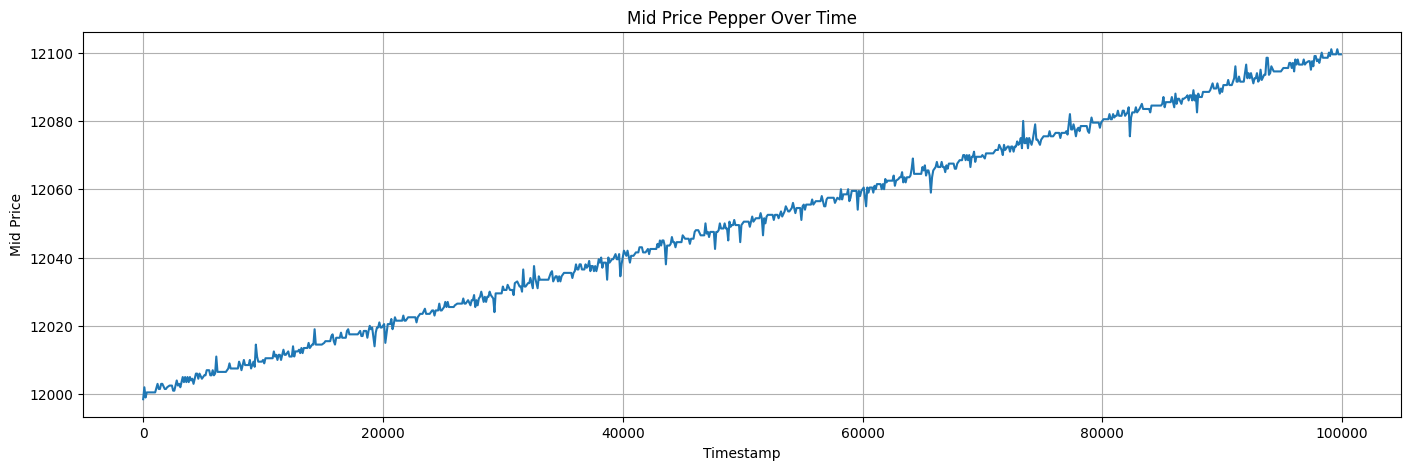

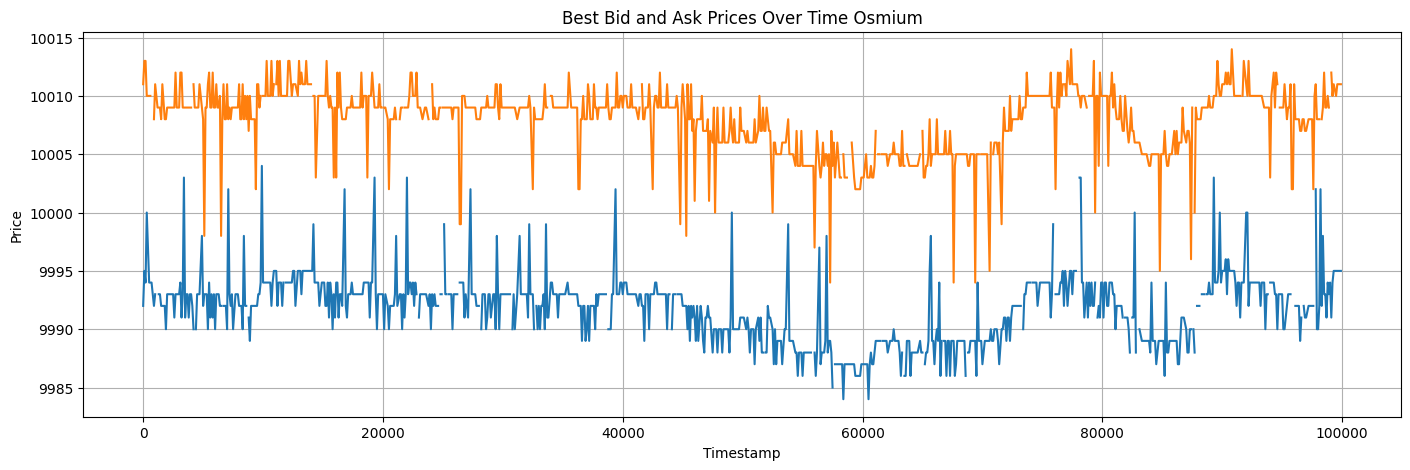

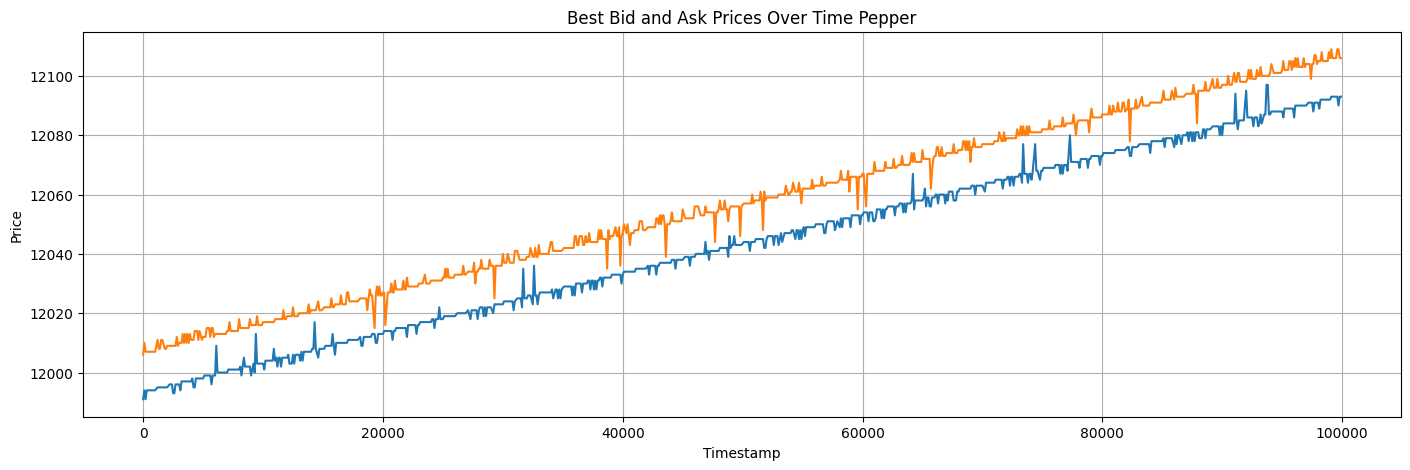

shape: (909, 3)
┌───────────┬───────────────────────────────┬────────────────────────────┐
│ timestamp ┆ position_INTARIAN_PEPPER_ROOT ┆ position_ASH_COATED_OSMIUM │
│ ---       ┆ ---                           ┆ ---                        │
│ f64       ┆ f64                           ┆ f64                        │
╞═══════════╪═══════════════════════════════╪════════════════════════════╡
│ 100.0     ┆ 11.0                          ┆ null                       │
│ 200.0     ┆ 31.0                          ┆ null                       │
│ 300.0     ┆ 41.0                          ┆ null                       │
│ 500.0     ┆ 60.0                          ┆ null                       │
│ 600.0     ┆ 60.0                          ┆ null                       │
│ …         ┆ …                             ┆ …                          │
│ 99500.0   ┆ 70.0                          ┆ 6.0                        │
│ 99600.0   ┆ 70.0                          ┆ 6.0                        │
│ 99700.0

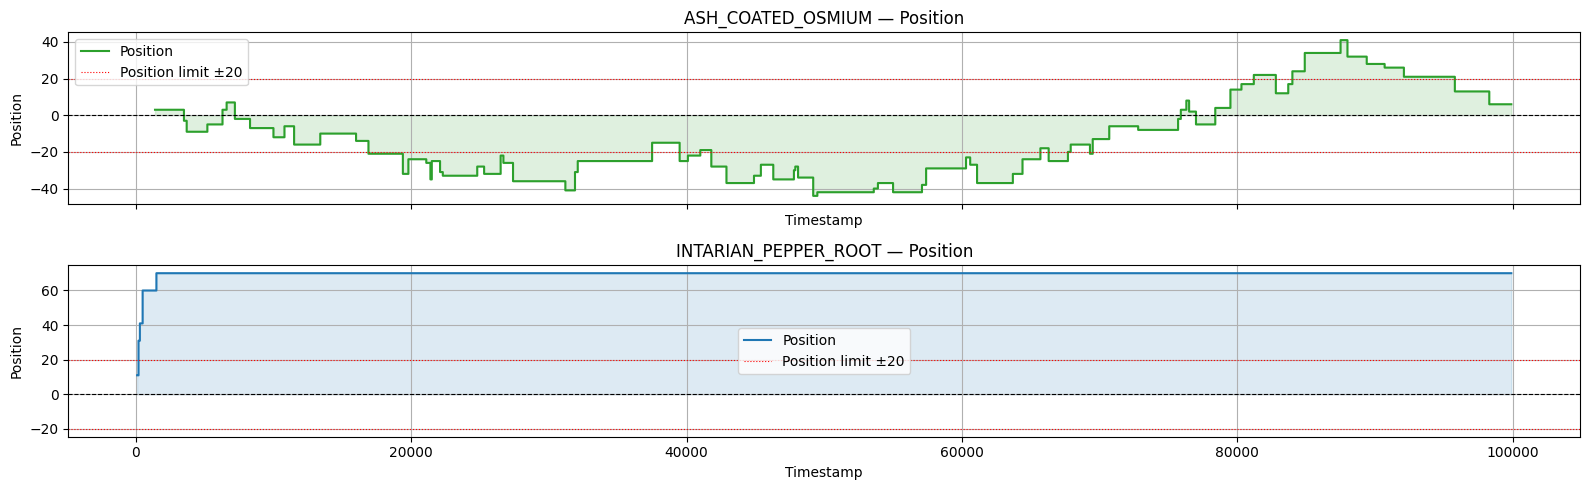


Trades CSV saved to: 156488/156488_trades.csv
shape: (88, 5)
┌──────────────────────┬──────┬─────────┬──────────┬─────────────────┐
│ product              ┆ side ┆ price   ┆ quantity ┆ trade_timestamp │
│ ---                  ┆ ---  ┆ ---     ┆ ---      ┆ ---             │
│ str                  ┆ str  ┆ f64     ┆ i64      ┆ i64             │
╞══════════════════════╪══════╪═════════╪══════════╪═════════════════╡
│ ASH_COATED_OSMIUM    ┆ BUY  ┆ 9994.0  ┆ 3        ┆ 1300            │
│ ASH_COATED_OSMIUM    ┆ SELL ┆ 10003.0 ┆ 6        ┆ 3400            │
│ ASH_COATED_OSMIUM    ┆ SELL ┆ 10008.0 ┆ 6        ┆ 3600            │
│ ASH_COATED_OSMIUM    ┆ BUY  ┆ 9998.0  ┆ 4        ┆ 5100            │
│ ASH_COATED_OSMIUM    ┆ BUY  ┆ 9994.0  ┆ 8        ┆ 6200            │
│ …                    ┆ …    ┆ …       ┆ …        ┆ …               │
│ INTARIAN_PEPPER_ROOT ┆ BUY  ┆ 12010.0 ┆ 20       ┆ 100             │
│ INTARIAN_PEPPER_ROOT ┆ BUY  ┆ 12007.0 ┆ 10       ┆ 200             │
│ INTARIAN_PEPP

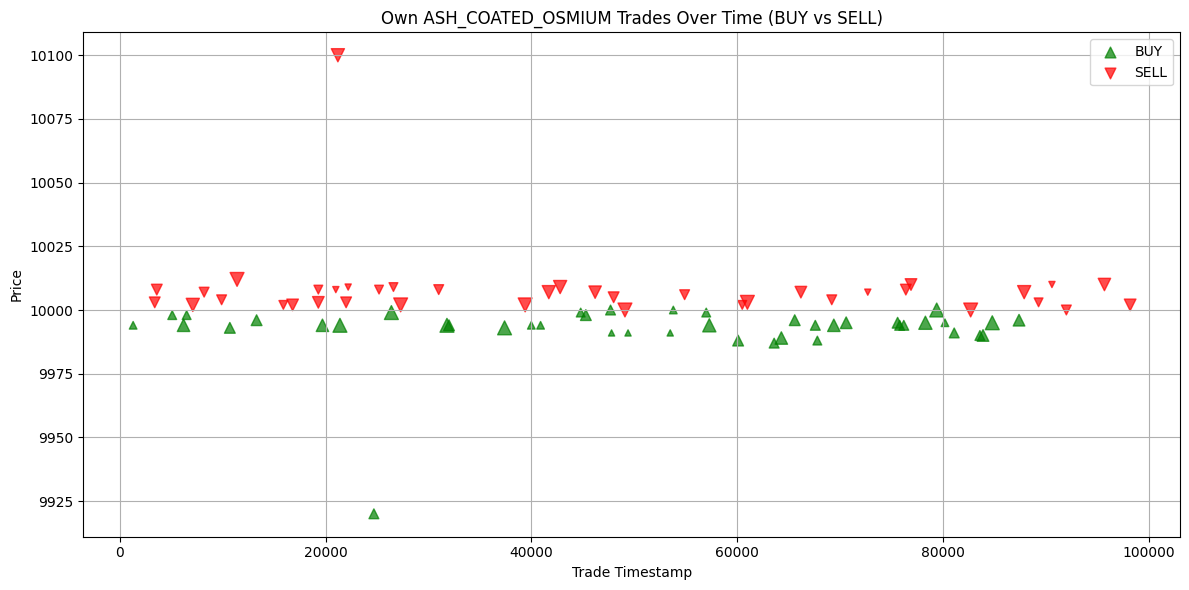

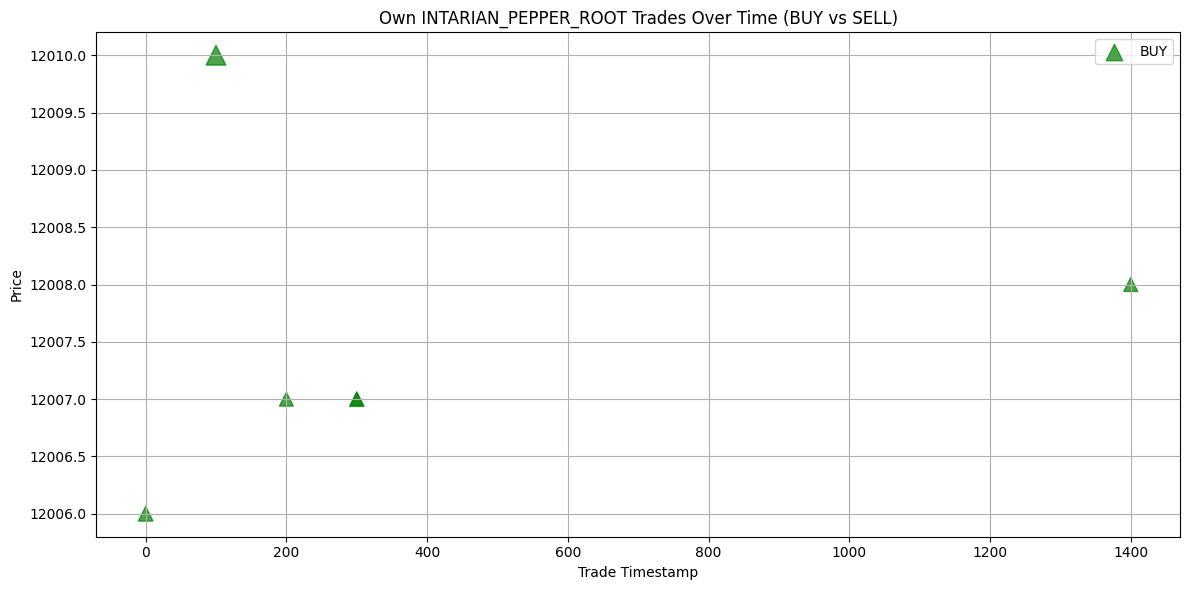


Enriched CSV saved to: ../156488/156488_enriched


In [296]:
import polars as pl
import json
import re
import sys
import json
import argparse
from pathlib import Path
from io import StringIO
import matplotlib.pyplot as plt

# FILTER = "ASH_COATED_OSMIUM"
# FILTER = "INTARIAN_PEPPER_ROOT"

def parse_log_file(path: str) -> pl.DataFrame:
    """
    Parse a trading log file (JSON with embedded CSV activitiesLog) into a Polars DataFrame.
    Supports both .json log files and raw .csv/.log files.
    """
    with open(path, "r") as f:
        content = f.read().strip()

    # Try JSON format first (log file wraps CSV in activitiesLog key)
    csv_text = None
    try:
        data = json.loads(content)
        csv_text = data.get("activitiesLog", "")
    except json.JSONDecodeError:
        # Might be raw CSV or a JSON-lines file — try extracting activitiesLog from first line
        first_line = content.split("\n")[0]
        try:
            data = json.loads(first_line)
            csv_text = data.get("activitiesLog", "")
        except json.JSONDecodeError:
            # Treat entire file as raw CSV
            csv_text = content

    if not csv_text:
        raise ValueError("No CSV data found in log file.")

    df = pl.read_csv(
        StringIO(csv_text),
        separator=";",
        null_values=[""],
        infer_schema_length=1000,
    )
    return df

def parse_own_trades(data: dict) -> pl.DataFrame:
    """Extract own trades from lambda logs into a DataFrame."""
    records = []
    for entry in data.get("logs", []):
        ts = entry.get("timestamp")
        lambda_log = entry.get("lambdaLog", "")

        match = re.search(r'Own Trades:\s*(\{.*?\})', lambda_log)
        if not match:
            continue

        raw = match.group(1).replace("'", '"')

        # Extract each product's trade list: "PRODUCT": [(...)]
        for product_match in re.finditer(r'"(\w+)":\s*\[([^\]]*)\]', raw):
            product = product_match.group(1)
            trades_str = product_match.group(2).strip()
            if not trades_str:
                continue

            # Each trade is a tuple: (SYMBOL, BUYER << SELLER, price, qty, timestamp)
            for trade_match in re.finditer(
                r'\((\w+),\s*(.*?),\s*([\d.]+),\s*(\d+),\s*(\d+)\)', trades_str
            ):
                raw_counterparty = trade_match.group(2).strip()
                # SUBMISSION << X  = we bought (we are buyer)
                # X << SUBMISSION  = we sold (we are seller)
                if "SUBMISSION <<" in raw_counterparty:
                    side = "BUY"
                elif "<< SUBMISSION" in raw_counterparty:
                    side = "SELL"
                else:
                    side = "UNKNOWN"

                records.append({
                    "log_timestamp": float(ts),
                    "product": product,
                    "side": side,
                    "price": float(trade_match.group(3)),
                    "quantity": int(trade_match.group(4)),
                    "trade_timestamp": int(trade_match.group(5)),
                    "counterparty": raw_counterparty,
                })

    if not records:
        return pl.DataFrame()

    return (
    pl.DataFrame(records)
    .unique(subset=["product", "side", "price", "quantity", "trade_timestamp"])
    .drop(["log_timestamp", "counterparty"])
    .sort(["product", "trade_timestamp"])
)

def plot_trades_osmium_directions(trades_df: pl.DataFrame) -> None:
    if trades_df.is_empty():
        print("No own trades found in logs.")
        return

    osmium_trades = trades_df.filter(pl.col("product") == "ASH_COATED_OSMIUM")

    if osmium_trades.is_empty():
        print("No ASH_COATED_OSMIUM trades found.")
        return

    # Convert to pandas for easy plotting (or use .to_numpy() if you prefer)
    df = osmium_trades.to_pandas()
    plt.figure(figsize=(12, 6))

    # Plot BUYs
    buy = df[df["side"] == "BUY"]
    if not buy.empty:
        plt.scatter(
            buy["trade_timestamp"],
            buy["price"],
            s=buy["quantity"] * 10,
            c="green",
            label="BUY",
            alpha=0.7,
            marker="^",
        )

    # Plot SELLs
    sell = df[df["side"] == "SELL"]
    if not sell.empty:
        plt.scatter(
            sell["trade_timestamp"],
            sell["price"],
            s=sell["quantity"] * 10,
            c="red",
            label="SELL",
            alpha=0.7,
            marker="v",
        )

    plt.title("Own ASH_COATED_OSMIUM Trades Over Time (BUY vs SELL)")
    plt.xlabel("Trade Timestamp")
    plt.ylabel("Price")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

def plot_trades_pepper_directions(trades_df: pl.DataFrame) -> None:
    if trades_df.is_empty():
        print("No own trades found in logs.")
        return

    pepper_trades = trades_df.filter(pl.col("product") == "INTARIAN_PEPPER_ROOT")

    if pepper_trades.is_empty():
        print("No INTARIAN_PEPPER_ROOT trades found.")
        return

    # Convert to pandas for easy plotting (or use .to_numpy() if you prefer)
    df = pepper_trades.to_pandas()
    plt.figure(figsize=(12, 6))

    # Plot BUYs
    buy = df[df["side"] == "BUY"]
    if not buy.empty:
        plt.scatter(
            buy["trade_timestamp"],
            buy["price"],
            s=buy["quantity"] * 10,
            c="green",
            label="BUY",
            alpha=0.7,
            marker="^",
        )

    # Plot SELLs
    sell = df[df["side"] == "SELL"]
    if not sell.empty:
        plt.scatter(
            sell["trade_timestamp"],
            sell["price"],
            s=sell["quantity"] * 10,
            c="red",
            label="SELL",
            alpha=0.7,
            marker="v",
        )

    plt.title("Own INTARIAN_PEPPER_ROOT Trades Over Time (BUY vs SELL)")
    plt.xlabel("Trade Timestamp")
    plt.ylabel("Price")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


def parse_trader_data(data: dict) -> pl.DataFrame:
    """Extract traderData fields from lambda logs into a DataFrame."""
    records = []
    for entry in data.get("logs", []):
        ts = entry.get("timestamp")
        lambda_log = entry.get("lambdaLog", "")
        
        # Extract traderData JSON from the log line
        match = re.search(r'traderData:\s*(\{.*\})', lambda_log)
        if match:
            try:
                td = json.loads(match.group(1))
                records.append({
                    "timestamp": ts,
                    "ash_coated_osmium_ma20": td.get("ash_coated_osmium_ma20"),
                    "ash_coated_osmium_ma20_trend": td.get("ash_coated_osmium_ma20_trend"),
                    "ash_coated_osmium_ma50": td.get("ash_coated_osmium_ma50"),
                    "ash_coated_osmium_ma50_trend": td.get("ash_coated_osmium_ma50_trend"),
                    "round_count": td.get("round_count"),
                })
            except json.JSONDecodeError:
                continue

    if not records:
        return pl.DataFrame()

    return pl.DataFrame(records).with_columns([
        pl.col("timestamp").cast(pl.Float64),
        pl.col("ash_coated_osmium_ma20").cast(pl.Float64),
        pl.col("ash_coated_osmium_ma20_trend").cast(pl.Float64),
    ])



def parse_positions(data: dict) -> pl.DataFrame:
    """Extract position data from lambda logs into a DataFrame."""
    records = []
    for entry in data.get("logs", []):
        ts = entry.get("timestamp")
        lambda_log = entry.get("lambdaLog", "")

        match = re.search(r'Position:\s*(\{.*?\})', lambda_log)
        if match:
            try:
                positions = json.loads(match.group(1).replace("'", '"'))
                record = {"timestamp": float(ts)}
                for product, pos in positions.items():
                    record[f"position_{product}"] = float(pos)
                records.append(record)
            except (json.JSONDecodeError, ValueError):
                continue

    return pl.DataFrame(records) if records else pl.DataFrame()


def plot_trader_data(td_df: pl.DataFrame, pos_df: pl.DataFrame) -> None:
    if td_df.is_empty():
        print("No traderData found in logs.")
        return
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 5), sharex=True)
    ax3, ax2 = axes


    # --- Position  Osmium---
    if not pos_df.is_empty() and "position_ASH_COATED_OSMIUM" in pos_df.columns:
        pos = pos_df.filter(pl.col("position_ASH_COATED_OSMIUM").is_not_null())
        ax3.plot(pos["timestamp"], pos["position_ASH_COATED_OSMIUM"], label="Position", color="tab:green", drawstyle="steps-post")
        ax3.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax3.axhline(20, color="red", linewidth=0.8, linestyle=":", label="Position limit ±20")
        ax3.axhline(-20, color="red", linewidth=0.8, linestyle=":")
        ax3.fill_between(pos["timestamp"].to_list(), pos["position_ASH_COATED_OSMIUM"].to_list(), 
                         step="post", alpha=0.15, color="tab:green")
    ax3.set_title("ASH_COATED_OSMIUM — Position")
    ax3.set_xlabel("Timestamp")
    ax3.set_ylabel("Position")
    ax3.legend()
    ax3.grid()


    # --- Position  Pepper ---
    if not pos_df.is_empty() and "position_INTARIAN_PEPPER_ROOT" in pos_df.columns:
        pos = pos_df.filter(pl.col("position_INTARIAN_PEPPER_ROOT").is_not_null())
        print(pos)
        ax2.plot(pos["timestamp"], pos["position_INTARIAN_PEPPER_ROOT"], label="Position", color="tab:blue", drawstyle="steps-post")
        ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax2.axhline(20, color="red", linewidth=0.8, linestyle=":", label="Position limit ±20")
        ax2.axhline(-20, color="red", linewidth=0.8, linestyle=":")
        ax2.fill_between(pos["timestamp"].to_list(), pos["position_INTARIAN_PEPPER_ROOT"].to_list(), 
                         step="post", alpha=0.15, color="tab:blue")
    ax2.set_title("INTARIAN_PEPPER_ROOT — Position")
    ax2.set_xlabel("Timestamp")
    ax2.set_ylabel("Position")
    ax2.legend()
    ax2.grid()


    plt.tight_layout()
    plt.show()

def clean_and_enrich(df: pl.DataFrame) -> pl.DataFrame:
    """Cast types and add derived columns."""
    # Ensure numeric types
    numeric_cols = [
        "timestamp", "bid_price_1", "bid_volume_1", "bid_price_2", "bid_volume_2",
        "ask_price_1", "ask_volume_1", "ask_price_2", "ask_volume_2",
        "mid_price", "profit_and_loss",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df = df.with_columns(pl.col(col).cast(pl.Float64, strict=False))

    df = df.with_columns([
        # Best bid-ask spread
        (pl.col("ask_price_1") - pl.col("bid_price_1")).alias("spread"),
        # Absolute mid-price change per product (requires sort first)
        pl.col("mid_price").diff().over("product").alias("mid_price_change"),
    ])
    return df


def summary_stats(df: pl.DataFrame) -> pl.DataFrame:
    """Per-product summary statistics."""
    return (
        df.group_by("product")
        .agg([
            pl.len().alias("ticks"),
            pl.col("profit_and_loss").last().alias("final_pnl"),
            pl.col("profit_and_loss").min().alias("min_pnl"),
            pl.col("profit_and_loss").max().alias("max_pnl"),
            pl.col("spread").mean().alias("avg_spread"),
            pl.col("spread").min().alias("min_spread"),
            pl.col("spread").max().alias("max_spread"),
            pl.col("mid_price").mean().alias("avg_mid"),
            pl.col("mid_price").std().alias("std_mid"),
            pl.col("bid_volume_1").mean().alias("avg_bid_vol"),
            pl.col("ask_volume_1").mean().alias("avg_ask_vol"),
        ])
        .sort("product")
    )


def pnl_by_timestamp(df: pl.DataFrame) -> pl.DataFrame:
    """P&L per product per timestamp, pivoted wide."""
    return (
        df.select(["timestamp", "product", "profit_and_loss"])
        .sort("timestamp")
        .pivot(on="product", index="timestamp", values="profit_and_loss")
    )


def spread_over_time(df: pl.DataFrame) -> pl.DataFrame:
    """Spread per product per timestamp."""
    return (
        df.select(["timestamp", "product", "spread"])
        .sort(["product", "timestamp"])
    )


def mid_price_over_time(df: pl.DataFrame) -> pl.DataFrame:
    """Mid price per product per timestamp."""
    return (
        df.select(["timestamp", "product", "mid_price"])
        .sort(["product", "timestamp"])
    )


def detect_pnl_plateau(df: pl.DataFrame, threshold: float = 1.0) -> pl.DataFrame:
    """
    Detect timestamps where P&L stops changing (possible position cap hit).
    Returns rows where |pnl_change| < threshold for each product.
    """
    return (
        df.sort(["product", "timestamp"])
        .with_columns(
            pl.col("profit_and_loss").diff().over("product").alias("pnl_change")
        )
        .filter(
            (pl.col("pnl_change").abs() < threshold) & pl.col("pnl_change").is_not_null()
        )
        .select(["timestamp", "product", "profit_and_loss", "pnl_change"])
    )


def print_pnl_summary(df: pl.DataFrame) -> None:
    """Print a summary of P&L statistics."""
    osmium = df.filter(pl.col("product") == "ASH_COATED_OSMIUM")
    pepper = df.filter(pl.col("product") == "INTARIAN_PEPPER_ROOT")
    plt.figure(figsize=(17, 5))
    plt.plot(pepper["timestamp"], pepper["profit_and_loss"])
    plt.plot(osmium["timestamp"], osmium["profit_and_loss"])
    plt.title("Profit and Loss Over Time")
    plt.xlabel("Timestamp")
    plt.ylabel("P&L")
    plt.grid()
    plt.show()

def print_mid_price_osmium(df: pl.DataFrame) -> None:
    osmium = df.filter(pl.col("product") == "ASH_COATED_OSMIUM")
    osmium = osmium.filter(pl.col("mid_price")!= 0)
    plt.figure(figsize=(17, 5))
    plt.plot(osmium["timestamp"], osmium["mid_price"])
    plt.title("Mid Price Osmium Over Time")
    plt.xlabel("Timestamp")
    plt.ylabel("Mid Price")
    plt.grid()
    plt.show()

def print_mid_price_pepper(df: pl.DataFrame) -> None:
    pepper = df.filter(pl.col("product") == "INTARIAN_PEPPER_ROOT")
    pepper = pepper.filter(pl.col("mid_price")!= 0)
    plt.figure(figsize=(17, 5))
    plt.plot(pepper["timestamp"], pepper["mid_price"])
    plt.title("Mid Price Pepper Over Time")
    plt.xlabel("Timestamp")
    plt.ylabel("Mid Price")
    plt.grid()
    plt.show()

def print_best_bid_ask_osmium(df: pl.DataFrame) -> None:
    osmium = df.filter(pl.col("product") == "ASH_COATED_OSMIUM")
    plt.figure(figsize=(17, 5))
    plt.plot(osmium["timestamp"], osmium["bid_price_1"], label="Best Bid")
    plt.plot(osmium["timestamp"], osmium["ask_price_1"], label="Best Ask")
    plt.title("Best Bid and Ask Prices Over Time Osmium")
    plt.xlabel("Timestamp")
    plt.ylabel("Price")
    plt.grid()
    plt.show()

def print_best_bid_ask_pepper(df: pl.DataFrame) -> None:
    pepper = df.filter(pl.col("product") == "INTARIAN_PEPPER_ROOT")
    plt.figure(figsize=(17, 5))
    plt.plot(pepper["timestamp"], pepper["bid_price_1"], label="Best Bid")
    plt.plot(pepper["timestamp"], pepper["ask_price_1"], label="Best Ask")
    plt.title("Best Bid and Ask Prices Over Time Pepper")
    plt.xlabel("Timestamp")
    plt.ylabel("Price")
    plt.grid()
    plt.show()

def print_report(df: pl.DataFrame) -> None:
    """Print a human-readable analysis report to stdout."""
    print("=" * 60)
    print("TRADING LOG ANALYSIS")
    print("=" * 60)

    print(f"\nTotal rows loaded : {len(df)}")
    print(f"Products          : {df['product'].unique().to_list()}")
    print(f"Timestamp range   : {int(df['timestamp'].min())} – {int(df['timestamp'].max())}")
    print(f"Days in log       : {df['day'].unique().to_list()}")

    print("\n--- Per-product summary ---")
    print(summary_stats(df))

    print("\n--- P&L pivot (first 10 rows) ---")
    print(pnl_by_timestamp(df).head(10))

    print("\n--- P&L plateaus (possible position cap) ---")
    plateaus = detect_pnl_plateau(df)
    if len(plateaus) > 0:
        print(plateaus.head(10))
    else:
        print("None detected.")


def pretty_print_log(input_path: str, output_path: str | None = None):
    text = Path(input_path).read_text(encoding="utf-8")

    # Parse outer JSON
    data = json.loads(text)

    # Unescape activitiesLog (literal \n -> real newlines)
    activities = data.get("activitiesLog", "")
    activities_clean = activities.replace("\\n", "\n").replace("\\t", "\t")

    # Pretty-print logs array
    logs = data.get("logs", [])

    out_path = output_path or Path(input_path).with_suffix(".readable.log")

    with open(out_path, "w", encoding="utf-8") as f:
        # ── Header ────────────────────────────────────────────────────────────
        f.write(f"submissionId: {data.get('submissionId', 'N/A')}\n")
        f.write("=" * 70 + "\n\n")

        # ── Activities log (the CSV) ──────────────────────────────────────────
        f.write("ACTIVITIES LOG\n")
        f.write("-" * 70 + "\n")
        f.write(activities_clean)
        f.write("\n\n")

        # ── Lambda logs per timestamp ─────────────────────────────────────────
        f.write("LAMBDA LOGS\n")
        f.write("-" * 70 + "\n")
        for entry in logs:
            ts = entry.get("timestamp", "?")
            lambda_log = entry.get("lambdaLog", "").strip()
            sandbox_log = entry.get("sandboxLog", "").strip()
            f.write(f"\n[t={ts}]\n")
            if lambda_log:
                for line in lambda_log.splitlines():
                    f.write(f"  {line}\n")
            if sandbox_log:
                f.write(f"  [sandbox] {sandbox_log}\n")

    print(f"Readable log written to: {out_path}")
    return str(out_path)



# ---------------------------------------------------------------------------
# Entry point
# ---------------------------------------------------------------------------

Version = 156488

if __name__ == "__main__":
    path = f"../{Version}/{Version}.log"

    try:
        df_raw = parse_log_file(path)
    except FileNotFoundError:
        print(f"File not found: {path}")
        sys.exit(1)

    pretty_print_log(path, output_path=f"../{Version}/{Version}_readable.log")
    df = clean_and_enrich(df_raw)
    print_report(df)
    print_pnl_summary(df)
    print_mid_price_osmium(df)
    print_mid_price_pepper(df)
    print_best_bid_ask_osmium(df)
    print_best_bid_ask_pepper(df)

    # Parse and plot traderData
    raw_data = json.loads(Path(path).read_text(encoding="utf-8"))
    td_df = parse_trader_data(raw_data)
    pos_df = parse_positions(raw_data)
    plot_trader_data(td_df, pos_df)
    trades_df = parse_own_trades(raw_data)

    if not trades_df.is_empty():
        trades_path = f"{Version}/{Version}_trades.csv"
        trades_df.write_csv("../" + trades_path)
        print(f"\nTrades CSV saved to: {trades_path}")
        print(trades_df)
        plot_trades_osmium_directions(trades_df)
        plot_trades_pepper_directions(trades_df)

    # Optionally export enriched data
    out_csv = path.replace(".log", "_enriched").replace(".json", "_enriched")
    df_osmium = df.filter(pl.col("product") == "ASH_COATED_OSMIUM")
    df_osmium.write_csv(out_csv + ".osmium.csv")
    df_pepper = df.filter(pl.col("product") == "INTARIAN_PEPPER_ROOT")
    df_pepper.write_csv(out_csv + ".pepper.csv")
    print(f"\nEnriched CSV saved to: {out_csv}")